In [3]:
print("matplotlib 版本:", plt.__version__)
plt.plot([1,2,3], [1,4,9])
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute '__version__'

matplotlib 版本: 3.10.9


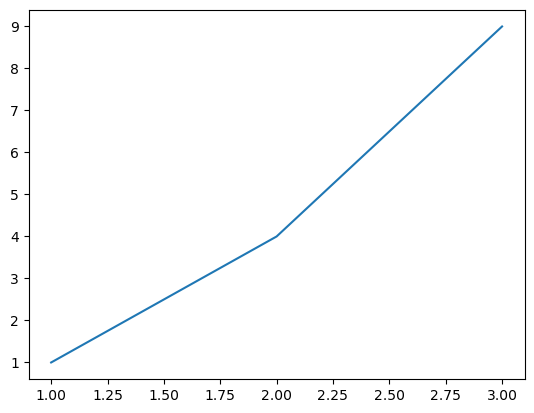

In [4]:
import matplotlib
print("matplotlib 版本:", matplotlib.__version__)
plt.plot([1,2,3], [1,4,9])
plt.show()

In [8]:
# 第一步：把所有工具都导入（每次重启内核后，先跑这个）
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 第二步：加载数据
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 第三步：画图
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 舱位等级 vs 生存率
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('不同舱位等级的生存率')
axes[0].set_xlabel('舱位等级 (1=头等舱, 3=三等舱)')
axes[0].set_ylabel('平均生存率')

# 性别 vs 生存率
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('不同性别的生存率')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('平均生存率')

plt.tight_layout()
plt.show()

RemoteDisconnected: Remote end closed connection without response

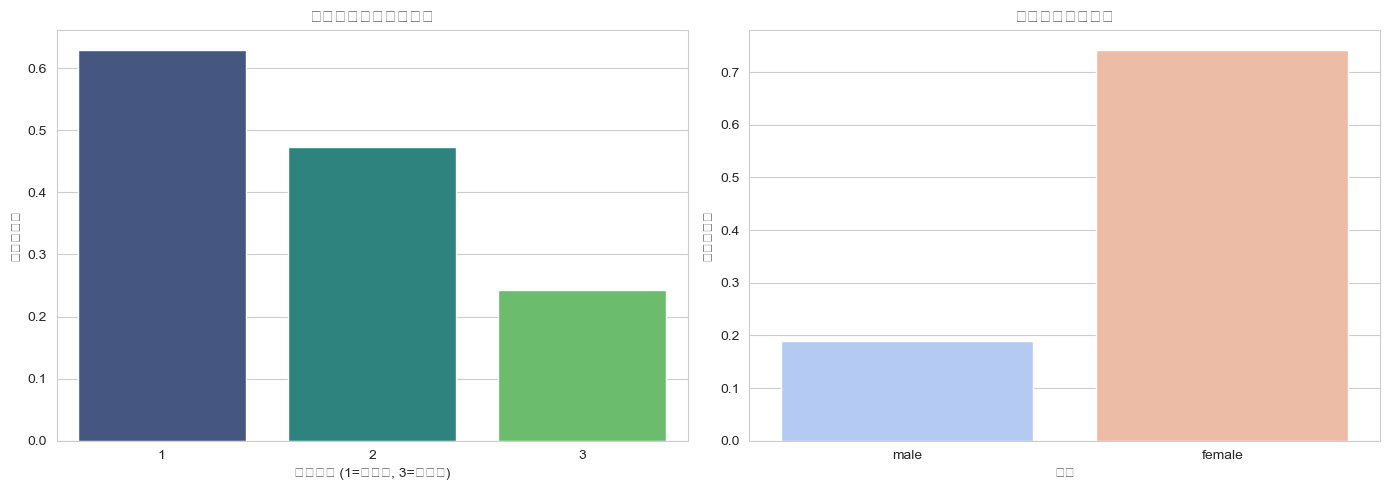

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')  # 暂时关闭警告，让输出干净

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 舱位等级 vs 生存率
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('不同舱位等级的生存率')
axes[0].set_xlabel('舱位等级 (1=头等舱, 3=三等舱)')
axes[0].set_ylabel('平均生存率')

# 性别 vs 生存率
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1], palette='coolwarm', errorbar=None)
axes[1].set_title('不同性别的生存率')
axes[1].set_xlabel('性别')
axes[1].set_ylabel('平均生存率')

plt.tight_layout()
plt.show()

In [11]:
df.to_csv('titanic.csv', index=False)

In [12]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
# 1. 删掉 Cabin 列，因为它缺太多，模型学不到东西
df.drop('Cabin', axis=1, inplace=True)

# 2. 用中位数填充 Age 缺失值（中位数不受极端年龄影响）
df['Age'].fillna(df['Age'].median(), inplace=True)

# 3. 用最频繁的登船港口填充 Embarked 的2个缺失
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. 再次检查是否还有缺失值
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [14]:
# 把性别变成 0/1（男=0，女=1）
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 把登船港口变成数字（S=0, C=1, Q=2）
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 扔掉不参与预测的列：PassengerId（编号）、Name（名字）、Ticket（票号）
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# 看看处理完的数据长什么样
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [15]:
# 第一步：把“要预测的”和“用来预测的”分开
# X = 特征矩阵（所有用来预测生存的列）
# y = 标签向量（我们想预测的 Survived 列）
X = df.drop('Survived', axis=1)  # 扔掉 Survived，剩下的全是特征
y = df['Survived']               # 只要 Survived

# 第二步：把数据切分成“训练集”和“测试集”
# 训练集用来学习规律，测试集用来验证学习效果
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 第三步：创建 SVM 模型并训练（这就是你之前浅显了解的 SVM！）
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=1.0, gamma='scale')  # 用最经典的 RBF 核
model.fit(X_train, y_train)  # 这一行代码，就是机器学习！

# 第四步：让模型在测试集上预测，并看看准确率
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"SVM 在测试集上的准确率: {accuracy:.2%}")

SVM 在测试集上的准确率: 65.36%


In [16]:
# 0. 重新拿到原始数据（我们加几个新特征进去）
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# 1. 特征工程：提取“家庭规模”和“称谓”
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)  # 是否孤身一人
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)  # 提取称谓
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df['Title'] = df['Title'].map(title_mapping)
df['Title'] = df['Title'].fillna(0)

# 2. 处理缺失值
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)

# 3. 编码文本特征
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. 丢掉用不到的列
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# 5. 分离特征和标签
X = df.drop('Survived', axis=1)
y = df['Survived']

# 6. 数据标准化（这是提升 SVM 准确率的关键）
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. 切分训练/测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 8. 训练 SVM
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=1.0, gamma='auto')
model.fit(X_train, y_train)

# 9. 预测并评估
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"优化后的 SVM 准确率: {accuracy:.2%}")

优化后的 SVM 准确率: 82.12%
